In [74]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tensorflow.keras.models import load_model

In [75]:
model = load_model("../models/MULTI_SESSION_MODEL.h5")

print("Model yuklendi!")

Model yuklendi!


In [76]:
id_to_user = {
    0: "aleyna",
    1: "damla",
    2: "deniz",
    3: "derya"
}

In [77]:
sample_path = "../real_test/aleyna_new_walk_01.csv"

In [78]:
rows = []

with open(sample_path, "r") as f:

    for line in f.readlines()[1:]:

        parts = line.strip().split(",")

        try:
            values = [float(x) for x in parts[1:]]

            # Sadece yeterli uzunlukta olanları al
            if len(values) >= 64:

                rows.append(values[:64])

        except:
            continue

data = np.array(rows)

print(data.shape)


(248, 64)


In [79]:
TARGET = 100

if data.shape[0] > TARGET:
    data = data[:TARGET]

elif data.shape[0] < TARGET:

    pad = TARGET - data.shape[0]

    data = np.pad(
        data,
        ((0,pad),(0,0)),
        mode='edge'
    )

print(data.shape)

(100, 64)


In [80]:
sample_mean = np.mean(data)
sample_std = np.std(data)

data = (
    data - sample_mean
) / (sample_std + 1e-8)

print(np.mean(data))
print(np.std(data))

1.1102230246251566e-17
0.999999999537517


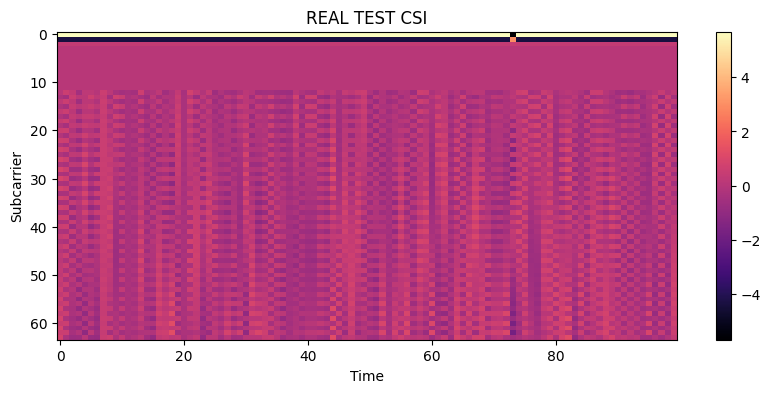

In [81]:
plt.figure(figsize=(10,4))

plt.imshow(
    data.T,
    aspect='auto',
    cmap='magma'
)

plt.title("REAL TEST CSI")

plt.xlabel("Time")
plt.ylabel("Subcarrier")

plt.colorbar()

plt.show()

In [82]:
sample_input = np.expand_dims(data, axis=0)

prediction = model.predict(sample_input)

pred_class = np.argmax(prediction)

confidence = np.max(prediction) * 100

print("Tahmin:", id_to_user[pred_class])

print(f"Güven: %{confidence:.2f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step
Tahmin: aleyna
Güven: %94.06


In [83]:
import glob
import os

files = glob.glob("../real_test/**/*.csv", recursive=True)

print("Toplam dosya:", len(files))

Toplam dosya: 27


In [84]:
results = []

for sample_path in files:

    # -------------------
    # LOAD
    # -------------------
    rows = []

    with open(sample_path, "r") as f:

        for line in f.readlines()[1:]:

            parts = line.strip().split(",")

            try:
                values = [float(x) for x in parts[1:]]

                if len(values) >= 64:
                    rows.append(values[:64])

            except:
                continue

    data = np.array(rows)

    # -------------------
    # FIX LENGTH
    # -------------------
    TARGET = 100

    if data.shape[0] > TARGET:
        data = data[:TARGET]

    elif data.shape[0] < TARGET:

        pad = TARGET - data.shape[0]

        data = np.pad(
            data,
            ((0,pad),(0,0)),
            mode='edge'
        )

    # -------------------
    # NORMALIZATION
    # -------------------
    sample_mean = np.mean(data)
    sample_std = np.std(data)

    data = (
        data - sample_mean
    ) / (sample_std + 1e-8)

    # -------------------
    # PREDICT
    # -------------------
    sample_input = np.expand_dims(data, axis=0)

    prediction = model.predict(
        sample_input,
        verbose=0
    )

    pred_class = np.argmax(prediction)

    confidence = np.max(prediction) * 100

    pred_name = id_to_user[pred_class]

    results.append([
        os.path.basename(sample_path),
        pred_name,
        confidence
    ])

In [85]:
for r in results:

    print(
        f"{r[0]} --> {r[1]} (%{r[2]:.2f})"
    )

aleyna_new_still_01.csv --> aleyna (%94.58)
aleyna_new_hand_clap_01.csv --> aleyna (%93.78)
aleyna_new_still_02.csv --> aleyna (%96.90)
aleyna_new_hand_clap_03.csv --> aleyna (%95.83)
aleyna_new_hand_clap_02.csv --> aleyna (%95.18)
aleyna_new_still_03.csv --> aleyna (%86.72)
aleyna_new_walk_02.csv --> aleyna (%93.50)
aleyna_new_bend_01.csv --> aleyna (%96.92)
aleyna_new_sit_down_01.csv --> aleyna (%95.49)
aleyna_new_walk_03.csv --> aleyna (%95.40)
aleyna_new_walk_01.csv --> aleyna (%94.06)
aleyna_new_sit_down_03.csv --> aleyna (%96.24)
aleyna_new_bend_02.csv --> aleyna (%97.34)
aleyna_new_bend_03.csv --> aleyna (%94.25)
aleyna_new_sit_down_02.csv --> aleyna (%96.50)
aleyna_new_horizontal_arm_wave_02.csv --> aleyna (%92.06)
aleyna_new_two_hands_wave_01.csv --> aleyna (%95.14)
aleyna_new_horizontal_arm_wave_03.csv --> aleyna (%96.90)
aleyna_new_horizontal_arm_wave_01.csv --> aleyna (%95.97)
aleyna_new_two_hands_wave_03.csv --> aleyna (%95.48)
aleyna_new_two_hands_wave_02.csv --> aleyna (